# Actor-Critic Methods in Reinforcement Learning

## 📚 Learning Objectives

By completing this notebook, you will:
- Implement actor–critic algorithms
- Combine policy and value learning

## 🔗 Prerequisites

- ✅ Basic Python
- ✅ Basic NumPy/Pandas (when applicable)

---

## Official Structure Reference

This notebook belongs to **Course 09, Unit 3**.

---


## Lesson Brief

This lesson introduces the **actor-critic** idea: one part of the system chooses actions, and another estimates how good states or actions are.

Students will see why combining a policy learner with a value estimator can reduce variance and make learning more stable.

Why this matters: actor-critic methods are the foundation of many practical RL algorithms used in continuous control and modern AI systems.

This lesson is a bridge from basic policy gradients to stronger methods like PPO.

## Recommended YouTube Video

To reinforce this lesson, watch **Machine Learning with Phil - "Everything You Need To Master Actor Critic Methods"**:
[Watch on YouTube](https://www.youtube.com/watch?v=LawaN3BdI00)

Why this pick:
- Clear non-Indian accent and beginner-friendly structure.
- Explains the separate jobs of the actor and critic before showing implementation.
- Good support for students moving beyond pure value methods.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Actor: learns the policy and chooses actions.
- Critic: estimates value information to guide the actor.
- Advantage-like signal: tells whether an action was better than expected.
- Shared loop: both learn from the same experience.
- Variance reduction: one reason actor-critic can be more stable than pure policy gradients.

### Quick Check
- What does the actor learn?
- What does the critic learn?
- Why can this be more stable than pure policy gradients?
- Why is the critic useful even though it does not choose the action?

### Common Mistakes
- Swapping actor and critic roles.
- Thinking the critic chooses actions.
- Forgetting they optimize different objectives.
- Thinking actor-critic is a totally different idea instead of a policy-gradient method with extra value guidance.


## Actor-Critic in Plain Language

Actor-critic methods answer a practical problem in deep RL:

`Can we keep the flexibility of policy gradients while giving the policy better feedback than raw returns alone?`

### The actor

The actor is the part that decides:

`What action should I take?`

So it learns the policy.

### The critic

The critic is the part that estimates how good the current situation or action is.
It does not choose the action. It provides a learning signal.

### Why combine them?

Pure policy gradients can work, but they often have high variance.
The critic helps the actor learn with more informative feedback, which can make updates more stable and data-efficient.

### Memory rule

- actor -> acts
- critic -> critiques

That simple sentence often prevents the most common student confusion.

## Inputs and Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---


### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


In [1]:
# Setup step: install the small packages needed for this lesson.
# Students can rerun this cell if the environment is missing a dependency.

# Line magic: Jupyter/IPython directive for this line only.
%pip install "gymnasium[classic_control]" torch numpy matplotlib -q
# Import names from a package/module into the notebook kernel namespace.
import torch
# Import names from a package/module into the notebook kernel namespace.
import torch.nn as nn
# Import names from a package/module into the notebook kernel namespace.
import torch.optim as optim
# Import names from a package/module into the notebook kernel namespace.
import gymnasium as gym
# Import names from a package/module into the notebook kernel namespace.
import numpy as np
# Import names from a package/module into the notebook kernel namespace.
import matplotlib.pyplot as plt
# Print text to the notebook cell output (console).
print('✅ Setup complete!')


You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


✅ Setup complete!


## Part 1: Actor-Critic Architecture


### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


In [2]:
# Model definition: this class packages one core RL concept into a reusable object.
# Read its state, methods, and update rules together so the algorithm feels concrete.

# Class `ActorCritic` (what it does): defines an object blueprint (attributes + methods); read the indented block to see each part.
class ActorCritic(nn.Module):
    # Function `__init__` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, obs_dim, act_dim.
    def __init__(self, obs_dim=4, act_dim=2):
        # Execute: super().__init__()
        super().__init__()
        # Assign/update a variable used later in this cell or in other cells.
        self.shared = nn.Sequential(
            # Call a PyTorch API (tensor/module/training-related).
            nn.Linear(obs_dim, 128),
            # Call a PyTorch API (tensor/module/training-related).
            nn.ReLU(),
        # Close the parentheses opened earlier (end this function call / grouping).
        )
        # Assign/update a variable used later in this cell or in other cells.
        self.actor_head = nn.Linear(128, act_dim)
        # Assign/update a variable used later in this cell or in other cells.
        self.critic_head = nn.Linear(128, 1)

    # Function `forward` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, x.
    def forward(self, x):
        # Assign/update a variable used later in this cell or in other cells.
        features = self.shared(x)
        # Create or update the greedy policy array (one int action id per state).
        policy_logits = self.actor_head(features)
        # Assign/update a variable used later in this cell or in other cells.
        state_value = self.critic_head(features)
        # Return a value from this function to its caller.
        return policy_logits, state_value


## Part 2: Training Loop


### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


In [3]:
# Helper function: this block isolates one piece of logic so students can study it in one place.
# Focus on the inputs, the returned value, and why this step is needed in the larger workflow.

# Function `train_actor_critic` (what it does): Minimal demonstration loop structure for actor-critic training.
def train_actor_critic(env_name='CartPole-v1', episodes=5):
    """Minimal demonstration loop structure for actor-critic training."""
    # Assign/update a variable used later in this cell or in other cells.
    env = gym.make(env_name)
    # Assign/update a variable used later in this cell or in other cells.
    model = ActorCritic()
    # Assign/update a variable used later in this cell or in other cells.
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    # Loop header: repeat the indented block for each item in the iterable.
    for episode in range(episodes):
        # Assign/update a variable used later in this cell or in other cells.
        obs, _ = env.reset()
        # Assign/update a variable used later in this cell or in other cells.
        total_reward = 0
        # Loop header: repeat the indented block for each item in the iterable.
        for _ in range(200):
            # Assign/update a variable used later in this cell or in other cells.
            obs_t = torch.tensor(obs).float().unsqueeze(0)
            # Assign/update a variable used later in this cell or in other cells.
            logits, value = model(obs_t)
            # Assign/update a variable used later in this cell or in other cells.
            dist = torch.distributions.Categorical(logits=logits)
            # Assign/update a variable used later in this cell or in other cells.
            action = dist.sample()
            # Assign/update a variable used later in this cell or in other cells.
            next_obs, reward, done, trunc, _ = env.step(action.item())

            # Context manager: setup/teardown around the indented block (files, locks, env).
            with torch.no_grad():
                # Assign/update a variable used later in this cell or in other cells.
                _, next_value = model(torch.tensor(next_obs).float().unsqueeze(0))
            # Compute one Bellman backup candidate: reward + gamma * V(next_state).
            target = reward + 0.99 * next_value.item() * (0 if (done or trunc) else 1)
            # Assign/update a variable used later in this cell or in other cells.
            advantage = target - value.item()

            # Assign/update a variable used later in this cell or in other cells.
            actor_loss = -dist.log_prob(action) * advantage
            # Assign/update a variable used later in this cell or in other cells.
            critic_loss = (value.squeeze() - target) ** 2
            # Assign/update a variable used later in this cell or in other cells.
            loss = actor_loss + critic_loss

            # Execute: optimizer.zero_grad()
            optimizer.zero_grad()
            # Execute: loss.backward()
            loss.backward()
            # Execute: optimizer.step()
            optimizer.step()

            # Assign/update a variable used later in this cell or in other cells.
            obs = next_obs
            # Assign/update a variable used later in this cell or in other cells.
            total_reward += reward
            # Branch: only run the next indented lines when this condition is true.
            if done or trunc:
                # Exit the nearest enclosing loop immediately.
                break
        # Print text to the notebook cell output (console).
        print(f"Episode {episode + 1}: reward={total_reward}")

    # Execute: env.close()
    env.close()
    # Return a value from this function to its caller.
    return model


# Assign/update a variable used later in this cell or in other cells.
_ = train_actor_critic(episodes=3)


Episode 1: reward=26.0
Episode 2: reward=55.0
Episode 3: reward=23.0


## Real-World Applications

- **Robotics**: Continuous control (robot arm, walking)
- **Autonomous Vehicles**: Steering, acceleration control
- **Game AI**: Real-time strategy games
- **Finance**: Portfolio optimization

---

**End of Notebook**

## 🌍 Contrast Example — REINFORCE on CartPole

**Industry context:**
- Actor-critic methods belong to the same broad policy-optimization family as simpler policy-gradient methods
- Robotics and control systems often move from simple policy gradients toward actor-critic and PPO-style methods
- This example is included as a contrast, not as a claim that REINFORCE equals actor-critic

We implement **REINFORCE** on CartPole-v1 so students can contrast it with the actor-critic structure introduced earlier in the notebook.

### Step Guide

**What this cell does:** This cell runs a worked example and shows the result through printed values, tables, or plots.

**Why this matters:** It is where the theory becomes concrete and students can connect the idea to actual behavior.

**What to expect in the output:** Expect visible output such as trajectories, value updates, rewards, comparisons, or charts.

**Common student confusion:** Students should compare the output with the comments and ask: what changed, why did it change, and what does that mean?


Episode   0 | Avg reward: 17.0
Episode  50 | Avg reward: 33.2


Episode 100 | Avg reward: 53.1


Episode 150 | Avg reward: 150.6


Episode 200 | Avg reward: 244.6


Episode 250 | Avg reward: 203.3


Episode 300 | Avg reward: 282.4


Episode 350 | Avg reward: 284.2


Episode 400 | Avg reward: 484.1


Episode 450 | Avg reward: 494.1


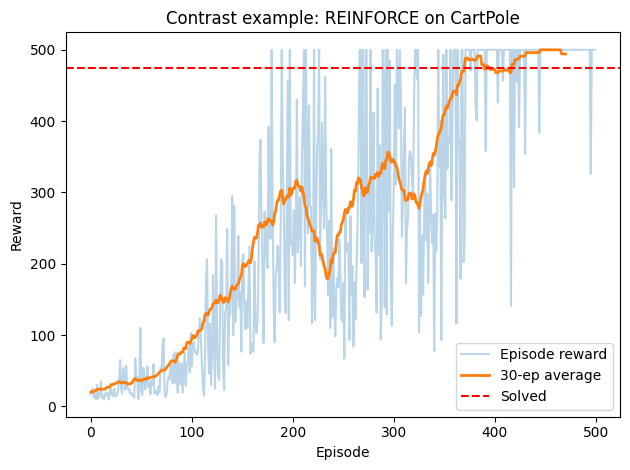

In [4]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Import names from a package/module into the notebook kernel namespace.
import torch, torch.nn as nn, torch.optim as optim
# Import names from a package/module into the notebook kernel namespace.
import gymnasium as gym
# Import names from a package/module into the notebook kernel namespace.
import numpy as np, matplotlib.pyplot as plt

# Call a PyTorch API (tensor/module/training-related).
torch.manual_seed(42)
# Assign/update a variable used later in this cell or in other cells.
env = gym.make('CartPole-v1')

# Class `PolicyNet` (what it does): defines an object blueprint (attributes + methods); read the indented block to see each part.
class PolicyNet(nn.Module):
    # Function `__init__` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self.
    def __init__(self):
        # Execute: super().__init__()
        super().__init__()
        # Assign/update a variable used later in this cell or in other cells.
        self.net = nn.Sequential(
            # Call a PyTorch API (tensor/module/training-related).
            nn.Linear(4, 128), nn.ReLU(),
            # Call a PyTorch API (tensor/module/training-related).
            nn.Linear(128, 2), nn.Softmax(dim=-1)
        # Close the parentheses opened earlier (end this function call / grouping).
        )
    # Function `forward` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, x.
    def forward(self, x): return self.net(x)

# Create or update the greedy policy array (one int action id per state).
policy  = PolicyNet()
# Assign/update a variable used later in this cell or in other cells.
opt     = optim.Adam(policy.parameters(), lr=2e-3)
# Set discount factor gamma used inside r + gamma * V(s') targets.
GAMMA   = 0.99; ep_rewards = []

# Loop header: repeat the indented block for each item in the iterable.
for episode in range(500):
    # Assign/update a variable used later in this cell or in other cells.
    obs,_ = env.reset(); log_probs=[]; rewards_ep=[]
    # Loop header: repeat the indented block for each item in the iterable.
    for _ in range(500):
        # Assign/update a variable used later in this cell or in other cells.
        probs  = policy(torch.tensor(obs).float().unsqueeze(0))
        # Assign/update a variable used later in this cell or in other cells.
        dist   = torch.distributions.Categorical(probs)
        # Assign/update a variable used later in this cell or in other cells.
        action = dist.sample()
        # Append one value to a list (mutates the list in place).
        log_probs.append(dist.log_prob(action))
        # Assign/update a variable used later in this cell or in other cells.
        obs, r, done, trunc, _ = env.step(action.item())
        # Append one value to a list (mutates the list in place).
        rewards_ep.append(r)
        # Branch: only run the next indented lines when this condition is true.
        if done or trunc: break

    # ── Compute discounted returns ──────────────────────────────────────────
    # Assign/update a variable used later in this cell or in other cells.
    G = 0; returns = []
    # Loop header: repeat the indented block for each item in the iterable.
    for r in reversed(rewards_ep):
        # Assign/update a variable used later in this cell or in other cells.
        G = r + GAMMA*G; returns.insert(0, G)
    # Assign/update a variable used later in this cell or in other cells.
    returns = torch.tensor(returns).float()
    # Assign/update a variable used later in this cell or in other cells.
    returns = (returns - returns.mean()) / (returns.std() + 1e-8)

    # ── Policy gradient loss ────────────────────────────────────────────────
    # Assign/update a variable used later in this cell or in other cells.
    loss = -torch.stack([lp*R for lp,R in zip(log_probs, returns)]).sum()
    # Execute: opt.zero_grad(); loss.backward(); opt.step()
    opt.zero_grad(); loss.backward(); opt.step()
    # Append one value to a list (mutates the list in place).
    ep_rewards.append(sum(rewards_ep))
    # Branch: only run the next indented lines when this condition is true.
    if episode%50==0: print(f"Episode {episode:3d} | Avg reward: {np.mean(ep_rewards[-20:]):.1f}")

# Execute: env.close()
env.close()
# Assign/update a variable used later in this cell or in other cells.
ma = np.convolve(ep_rewards, np.ones(30)/30, 'valid')
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.plot(ep_rewards, alpha=0.3, label="Episode reward")
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.plot(ma, lw=2, label="30-ep average")
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.axhline(475, color='red', linestyle='--', label="Solved")
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.title("Contrast example: REINFORCE on CartPole")
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.xlabel("Episode"); plt.ylabel("Reward"); plt.legend(); plt.tight_layout(); plt.show()


## 📚 References & Further Reading

**Papers:**
- Williams (1992) — [REINFORCE](https://link.springer.com/article/10.1007/BF00992696)
- Schulman et al. (2017) — [PPO: Proximal Policy Optimization](https://arxiv.org/abs/1707.06347)
- Mnih et al. (2016) — [A3C: Asynchronous Methods for Deep RL](https://arxiv.org/abs/1602.01783)

**State-of-the-Art:**
- OpenAI's ChatGPT uses RLHF (PPO) to align responses with human preferences
- Boston Dynamics robots use PPO for locomotion control

## 📝 Summary

You learned that **Actor-Critic** combines a policy learner with a value estimator so the policy update has better guidance and typically lower variance than plain REINFORCE. **PPO** can be understood as a later practical refinement built on this broader family of policy-optimization ideas.

### Step Guide

**What this cell does:** This cell turns the lesson outputs into a final visual recap.

**Why this matters:** Weak coders often understand charts faster than raw arrays or printed dictionaries.

**What to expect in the output:** Expect one or more plots that summarize the most important numbers from the notebook.

**Common student confusion:** Students should use this as a summary view after understanding the earlier steps, not as a replacement for them.


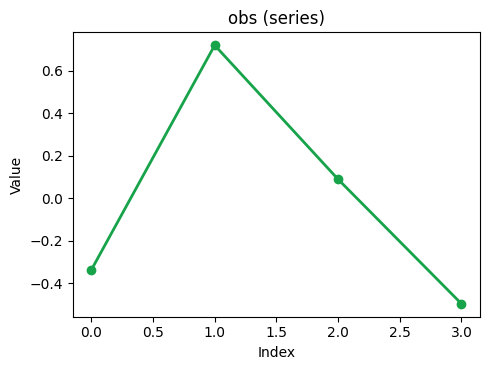

In [5]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
# Import names from a package/module into the notebook kernel namespace.
import numbers
# Import names from a package/module into the notebook kernel namespace.
import numpy as np
# Import names from a package/module into the notebook kernel namespace.
import matplotlib.pyplot as plt

# Function `_is_number` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _is_number(value):
    # Return a value from this function to its caller.
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

# Function `_as_numeric_dict` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _as_numeric_dict(value):
    # Branch: only run the next indented lines when this condition is true.
    if not isinstance(value, dict) or not value or len(value) > 12:
        # Return a value from this function to its caller.
        return None
    # Collect numeric dict values after validation for plotting.
    converted = []
    # Loop header: repeat the indented block for each item in the iterable.
    for item in value.values():
        # Branch: only run the next indented lines when this condition is true.
        if not _is_number(item):
            # Return a value from this function to its caller.
            return None
        # Append one value to a list (mutates the list in place).
        converted.append(float(item))
    # Return a value from this function to its caller.
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

# Function `_as_numeric_array` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value, dims.
def _as_numeric_array(value, dims):
    # Try/except/finally: structured error handling around risky operations.
    try:
        # Temporary ndarray after coercion attempt inside _as_numeric_array().
        array = np.asarray(value, dtype=float)
    # Try/except/finally: structured error handling around risky operations.
    except Exception:
        # Return a value from this function to its caller.
        return None
    # Branch: only run the next indented lines when this condition is true.
    if array.ndim != dims:
        # Return a value from this function to its caller.
        return None
    # Branch: only run the next indented lines when this condition is true.
    if dims == 1 and not (2 <= array.size <= 200):
        # Return a value from this function to its caller.
        return None
    # Branch: only run the next indented lines when this condition is true.
    if dims == 2 and array.size > 400:
        # Return a value from this function to its caller.
        return None
    # Return a value from this function to its caller.
    return array

# Preferred global names to try first when auto-picking lesson plots.
priority_names = [
    # Execute: "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    # Execute: "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores …
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
# Execute: ]
]

# Names that are never lesson metrics (imports / plotting handles).
skip_names = {"np", "plt", "numbers", "math"}
# Assign/update a variable used later in this cell or in other cells.
candidates = []
# Track which names were already visited to avoid duplicates.
seen = set()
# Ordered list of global names to scan for plottable numeric artifacts.
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

# Loop header: repeat the indented block for each item in the iterable.
for name in search_space:
    # Branch: only run the next indented lines when this condition is true.
    if name in seen or name not in globals() or name in skip_names:
        # Skip the rest of this loop body and jump to the next iteration.
        continue
    # Execute: seen.add(name)
    seen.add(name)
    # The runtime object bound to that global name.
    value = globals()[name]

    # Try to interpret a global variable as a plottable payload (or None if not).
    dict_payload = _as_numeric_dict(value)
    # Branch: only run the next indented lines when this condition is true.
    if dict_payload is not None:
        # Append one value to a list (mutates the list in place).
        candidates.append(("dict", name, dict_payload))
        # Branch: only run the next indented lines when this condition is true.
        if len(candidates) == 3:
            # Exit the nearest enclosing loop immediately.
            break
        # Skip the rest of this loop body and jump to the next iteration.
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_2d = _as_numeric_array(value, 2)
    # Branch: only run the next indented lines when this condition is true.
    if array_2d is not None:
        # Append one value to a list (mutates the list in place).
        candidates.append(("heatmap", name, array_2d))
        # Branch: only run the next indented lines when this condition is true.
        if len(candidates) == 3:
            # Exit the nearest enclosing loop immediately.
            break
        # Skip the rest of this loop body and jump to the next iteration.
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_1d = _as_numeric_array(value, 1)
    # Branch: only run the next indented lines when this condition is true.
    if array_1d is not None:
        # Append one value to a list (mutates the list in place).
        candidates.append(("line", name, array_1d))
        # Branch: only run the next indented lines when this condition is true.
        if len(candidates) == 3:
            # Exit the nearest enclosing loop immediately.
            break

# Branch: only run the next indented lines when this condition is true.
if not candidates:
    # Build a small dict used only for the fallback summary bar chart.
    summary = {
        # Execute: "functions": sum(callable(value) for value in globals().values()),
        "functions": sum(callable(value) for value in globals().values()),
        # Execute: "classes": sum(isinstance(value, type) for value in globals().values()),
        "classes": sum(isinstance(value, type) for value in globals().values()),
        # Execute: "numeric vars": sum(_is_number(value) for value in globals().values()),
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    # Part of a dict/set literal layout (syntax grouping).
    }
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, ax = plt.subplots(figsize=(6, 3.5))
    # Configure a subplot axis (limits, ticks, labels, or artists).
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    # Configure a subplot axis (limits, ticks, labels, or artists).
    ax.set_title("Notebook artifact summary")
    # Configure a subplot axis (limits, ticks, labels, or artists).
    ax.set_ylabel("Count")
    # Loop header: repeat the indented block for each item in the iterable.
    for idx, value in enumerate(summary.values()):
        # Configure a subplot axis (limits, ticks, labels, or artists).
        ax.text(idx, value + 0.05, str(value), ha="center")
    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.tight_layout()
    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.show()
# Else branch: runs when the matching if/elif chain was not taken.
else:
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    # Branch: only run the next indented lines when this condition is true.
    if len(candidates) == 1:
        # Assign/update a variable used later in this cell or in other cells.
        axes = [axes]

    # Loop header: repeat the indented block for each item in the iterable.
    for ax, (kind, name, payload) in zip(axes, candidates):
        # Branch: only run the next indented lines when this condition is true.
        if kind == "dict":
            # Unpack plotting payload for dict bar charts (keys vs numeric values).
            labels, values = payload
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.bar(range(len(values)), values, color="#2563eb")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_xticks(range(len(values)))
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_xticklabels(labels, rotation=45, ha="right")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_title(f"{name} (dict)")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_ylabel("Value")
        # Else-if branch: checked only when previous conditions were false.
        elif kind == "line":
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_title(f"{name} (series)")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_xlabel("Index")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_ylabel("Value")
        # Else branch: runs when the matching if/elif chain was not taken.
        else:
            # Image handle returned by imshow for attaching a colorbar.
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_title(f"{name} (heatmap)")
            # Configure or update the active Matplotlib Figure object.
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.tight_layout()
    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.show()


## Closing Takeaway

**Teaching takeaway:** Actor-critic methods combine a policy learner with a value-based guide so each part supports the other during training.

**If students remember one idea:** The actor decides what to do, while the critic evaluates how good the decision appears to be.

**Quick check before moving on:**
- Can you explain the separate jobs of the actor and the critic?
- Can you describe why the critic can reduce variance in policy learning?

**Bridge to the next step:** This prepares students for PPO, which adds practical constraints that make policy optimization more stable.
